### Max Likelihood Estimate for Truncated/Censored Data

For a function, $S(x)$. $S(x) = 0$ when $x > x_{max}$. And hence we can say the dataset is truncated, where we know nothing about sources that are greater than $x_max$.

So truncated data causes an object to be missing, this means that our observed sample is not a random sample from the entire Gaussian (assume this distribution).

The original Gaussian would include the probabilities of the truncated section, so we must renormalise our surviving section.

$$p_{\text{trunc}} (x| \mu, \sigma) = \frac{p(x | \mu, \sigma)}{F(x_{max}| \mu, \sigma) - F(x_{min} | \mu, \sigma)}$$

Where the denominator represents the total probability area between the lower and upper bound.

Hence, we get the following PDF for a truncated normal distribution:

$$p(x_i|\mu,\sigma,x_{\text{min}},x_{\text{max}}) = C(\mu,\sigma, x_{\text{min}},x_{\text{max}}) \frac{1}{\sqrt{2\pi}\sigma} \exp \bigg(\frac{-(x_i-\mu)^2}{2\sigma^2}\bigg)$$

And so the log-likelihood is:

$$\quad \ln L(\mu) = \text{constant} - \sum^N_{i=1} \frac{(x_i-\mu)^2}{2\sigma^2} + N \ln [C(\mu,\sigma, x_{\text{min}},x_{\text{max}})].\quad (3)$$

In conjunction with this, censored data is when a measurement of an existing source is attempted but the value is outside a known interval.

So truncated data causes an object to be missing, while within censored data, the object is present but its value is bounded.

Mean = 50.5


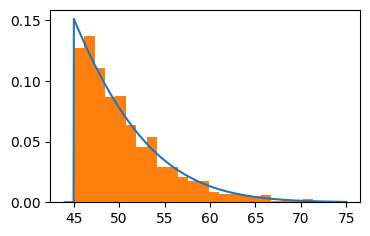

In [2]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import truncnorm
from matplotlib import pyplot as plt

fig = plt.subplots(figsize=(4, 2.5))

x = np.linspace(44, 75, 1000)
mean = 25
std = 13
x_min = 45
x_max = np.inf
a, b = (x_min - mean) / std, (x_max - mean) / std
r = truncnorm.rvs(a, b, loc = mean, scale = std, size=1000)
plt.plot(x, truncnorm.pdf(x,a,b,loc = mean, scale = std));
plt.hist(r, bins = 'fd', density = True);
print(f'Mean = {np.mean(r):.3}')


### Fitting a Line to Data

Let's say our measurements approximately follow a straight line, and the scatter in our measurements is generated by a gaussian process:

$$y_i = ax_i + b + r_i$$

where $x_i$ is the measured or known input, $y_i$ is the measured output, a is the gradient, b is the intercept and $r_i$ is the residual.

As we stated, $r_i$ is drawn from $N(0, \sigma)$. Where $\sigma$ is the measurement uncertainty and we say its the same for all points.

We can see that the data model has a linear relationship with two parameters $a,b$ and so our model can be written as $M(a,b)$

We first wish to calculate the likelihood, asking ourselves what is the probability $p(y_i|x_i, M(a, b), \sigma)$ that a particular point $y_i$ would be measured. This is the normal distribution

$$p(y_i|x_i, M(a, b), \sigma) = N(y_i - M(x_i)|\sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( - \frac{(y_i - M(x_i))^2}{2 \sigma^2} \right).$$

Now since we want to calculate the likelihood, lets do the product over N of these terms. And then because we turn it into a log-likelihood, it becomes a sum:

$$\ln L(a, b) = \mathrm{constant} - \frac{1}{2} \sum_{i=1}^N \frac{(y_i - M(x_i))^2}{\sigma^2} = \mathrm{constant} - \frac{1}{2} \chi^2$$

We now maximise this expression with respect to a and b. This is equivalent to minimising the sum of the squares in a least-squares method.

In [3]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize

from astroML import stats as astroMLstats
from astroML.datasets import fetch_hogg2010test


(12.0, 300.0)

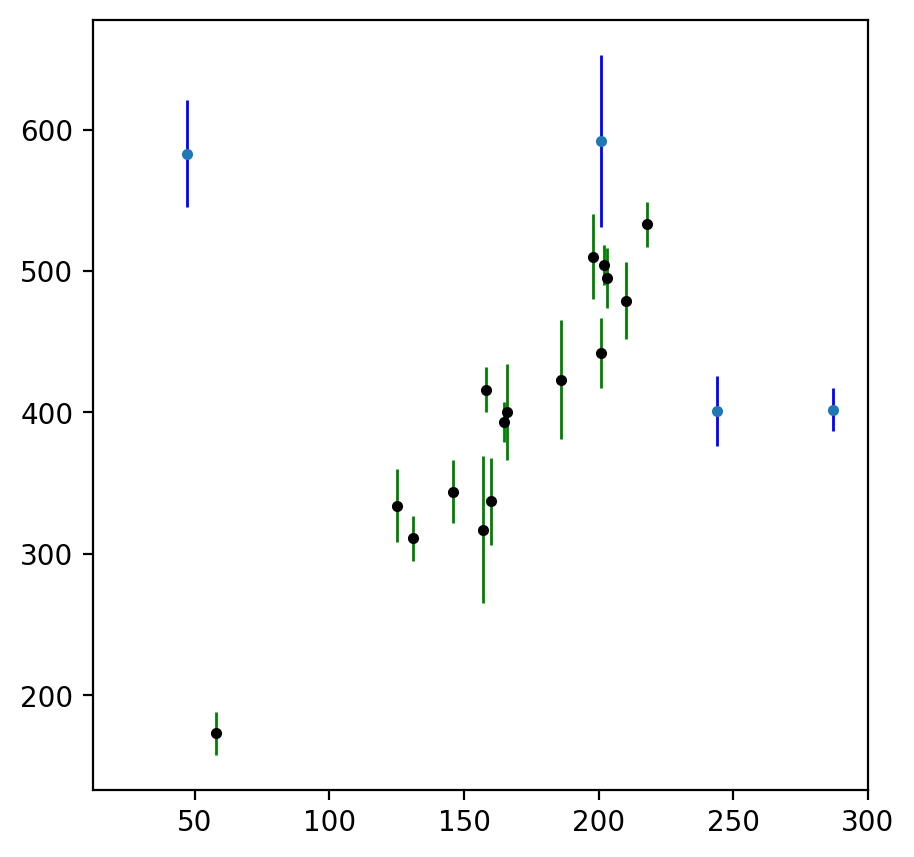

In [4]:
data = fetch_hogg2010test()

x = data['x']
y = data['y']
dy = data['sigma_y']


#plotting

fig = plt.figure(figsize= (5,5))
ax = fig.add_subplot(111) # 1 row, 1 column, select the first subplot

ax.errorbar(x[4:], y[4:], dy[4:], fmt = ".k", lw = 1, ecolor= "g")
ax.errorbar(x[:4], y[:4], dy[:4], fmt = ".", lw = 1, ecolor= "b")
ax.set_xlim(12,300)


Now perform a weighted least squares fit of a linear relationship

In [5]:
def squared_loss(m,b,x,y,dy):
    y_fit = m*x +b
    return np.sum(((y-y_fit)/ dy)**2, -1) # -1 here means to sum along the final array axis


This function calculates $$\chi^2(m,b) = \sum_i \left( \frac{y_i - (mx_i +b)}{dy_i} \right)^2$$

In [6]:
f_squared = lambda beta: squared_loss(beta[0], beta[1], #This optimiser expects a function that accepts a single array like parameter, beta[0] is the slope
                                      x=x[4:], y=y[4:], 
                                      dy=dy[4:])
beta0 = (1,30) # initial guesses for a and b
beta_mle = optimize.fmin(f_squared, beta0)

print(beta_mle) # these is our best fitting line


Optimization terminated successfully.
         Current function value: 18.680770
         Iterations: 53
         Function evaluations: 106
[ 2.23992089 34.04772524]


Now lets plot the results, we have found a line of:

$$y = 2.24x + 34.0$$

(12.0, 300.0)

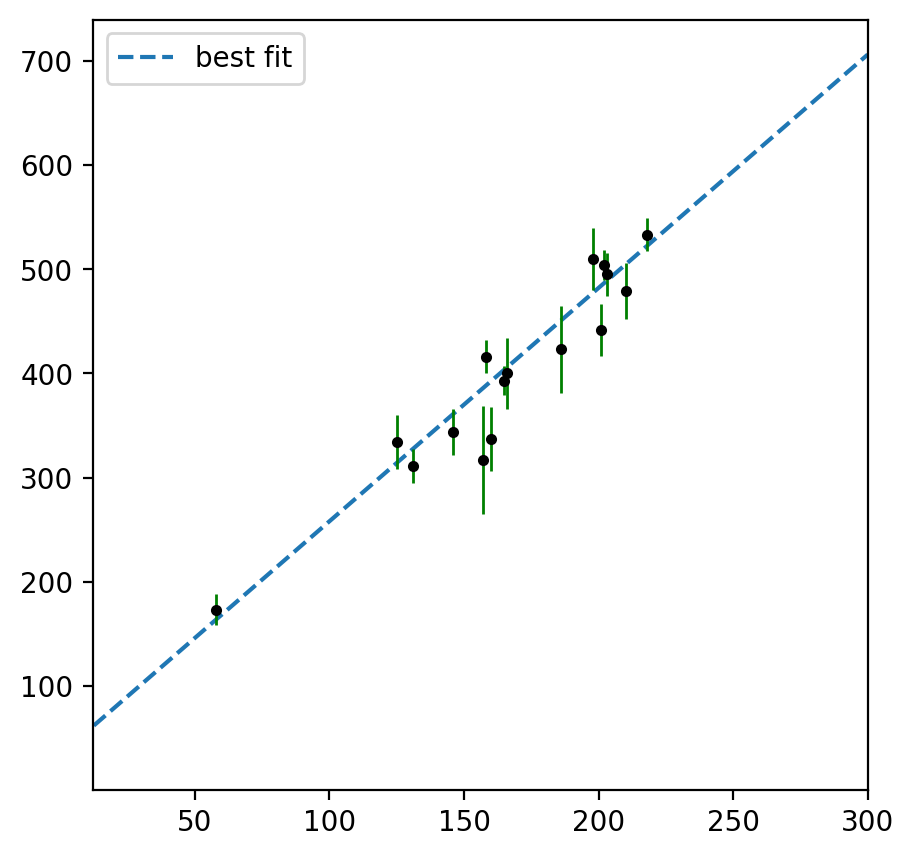

In [7]:
data = fetch_hogg2010test()

x = data['x']
y = data['y']
dy = data['sigma_y']

x_fit = np.linspace(0,300,100)


#plotting

fig = plt.figure(figsize= (5,5))
ax = fig.add_subplot(111) # 1 row, 1 column, select the first subplot
ax.plot(x_fit, beta_mle[0] *x_fit + beta_mle[1], label = "best fit", ls = "--")
ax.errorbar(x[4:], y[4:], dy[4:], fmt = ".k", lw = 1, ecolor= "g")
plt.legend()
plt.plot()
ax.set_xlim(12,300)


This has been using the initial data, but what happens when we include the contaminated data?

Optimization terminated successfully.
         Current function value: 5.890787
         Iterations: 69
         Function evaluations: 131
Optimization terminated successfully.
         Current function value: 289.963723
         Iterations: 70
         Function evaluations: 133
[  1.07674734 213.27353024] [ -0.79164434 624.98691792]


(12.0, 300.0)

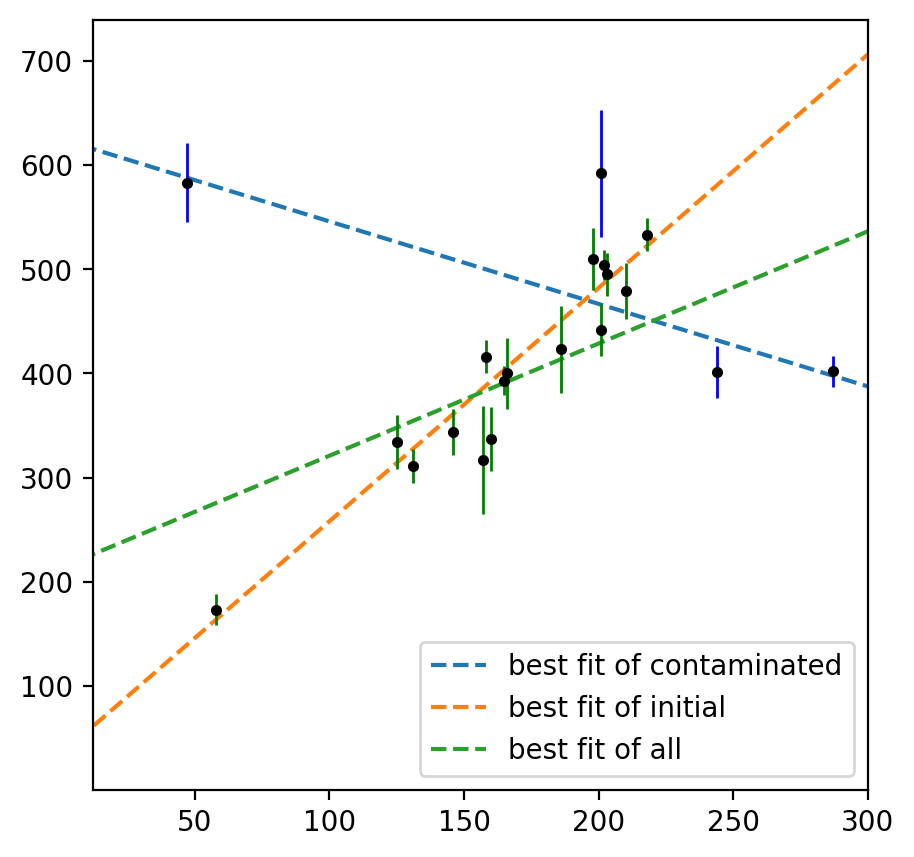

In [8]:
f_squared_outliers = lambda beta2: squared_loss(beta2[0], beta2[1], 
                                      x=x[:4], y=y[:4], 
                                      dy=dy[:4])
f_squaredall = lambda beta1: squared_loss(beta1[0], beta1[1], 
                                      x=x, y=y, 
                                      dy=dy)

beta0 = (1,30) # initial guesses for a and b
beta_mle_outliers = optimize.fmin(f_squared_outliers, beta0)
beta_mle1 = optimize.fmin(f_squaredall, beta0)

print(beta_mle1, beta_mle_outliers) # these is our best fitting line for the outliers

x = data['x']
y = data['y']
dy = data['sigma_y']

x_fit = np.linspace(0,300,100)
#plotting

fig = plt.figure(figsize= (5,5))
ax = fig.add_subplot(111) # 1 row, 1 column, select the first subplot
ax.plot(x_fit, beta_mle_outliers[0] *x_fit + beta_mle_outliers[1], label = "best fit of contaminated", ls = "--")
ax.plot(x_fit, beta_mle[0] *x_fit + beta_mle[1], label = "best fit of initial", ls = "--")
ax.plot(x_fit, beta_mle1[0] * x_fit + beta_mle1[1], label = "best fit of all", ls = "--")
ax.errorbar(x[4:], y[4:], dy[4:], fmt = ".k", lw = 1, ecolor= "g")
ax.errorbar(x[:4], y[:4], dy[:4], fmt = ".k", lw = 1, ecolor = "b")
plt.legend()
plt.plot()
ax.set_xlim(12,300)


So how do we deal with this?

We know that

1. Summing the squares of the residuals is sensitive to outliers
2. $\chi^2$ is an example of an $L_2$ norm where the $L_p \text{norm} = \sum^N_{i=1} (y_i - M(x_i))^p / \sigma^p$
3. There are various approaches for correcting outliers: Sigma clipping, IQR, Taking the median solutions of subsets of data, least trimmed squares, etc

We can also change the likelihood to reduce the weight of the outliers, called the Huber loss function

$$\sum_{i=1}^N e(y_i|y),$$

where

$$
e(t) = \left\{
\begin{array}{ll}
\frac{1}{2} t^2 & \text{if} \; |t| \leq c, \\
c|t| - \frac{1}{2} c^2 & \text{if} \; |t| \geq c,
\end{array}
\right )
$$

and

$$t = \left|\frac{y-M(x)}{\sigma}\right|.$$

We can see that t measures how far the observations lie from the model in units of uncertainty

Applying this:

In [9]:
# Define the log-likelihood via the Huber loss function
def huber_loss(m, b, x, y, dy, c=1):
    y_fit = m * x + b # model, calculates predicted value for each observation
    t = abs((y - y_fit) / dy) # define t, absolute value of the standardised residuals
    mask = t > c # define mask for large excursion points
    
    # apply masking to different points
    # note '~' means 'not'
    return np.sum(np.logical_not(mask) * (0.5 * t ** 2) - \
                  (mask) * c * (0.5 * c - t), -1)


c=5

# lambda function for huber loss 
f_huber = lambda beta: huber_loss(beta[0], beta[1], 
                                  x=x, y=y, dy=dy, c=c)

#------------------------------------------------------------
# compute the maximum likelihood using the huber loss
beta0 = (1, 30)
beta_huber = optimize.fmin(f_huber, beta0)


Optimization terminated successfully.
         Current function value: 128.157106
         Iterations: 66
         Function evaluations: 127


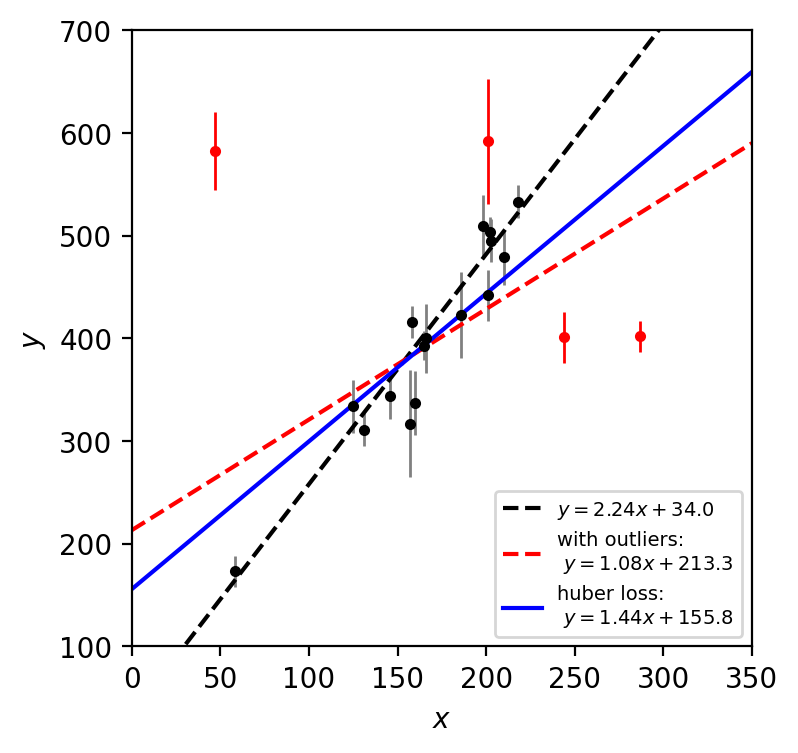

In [10]:
# Plot the results
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)

# plot the data without outliers in gray
ax.errorbar(x[4:], y[4:], dy[4:], 
            fmt='.k', lw=1, ecolor='gray')
# plot the outliers in red
ax.errorbar(x[:4], y[:4], dy[:4], 
            fmt='.', lw=1, color='red')

x_fit = np.linspace(0, 350, 10)
# plot the regular fit from before without outliers
ax.plot(x_fit, beta_mle[0] * x_fit + beta_mle[1], 
        ls='--', color='k',
        label="$y=%.2fx + %.1f$" % tuple(beta_mle))
# plot the fit that includes outliers
ax.plot(x_fit, beta_mle1[0] * x_fit + beta_mle1[1], 
        ls='--', color='red',
        label="with outliers:\n $y=%.2fx + %.1f$" % tuple(beta_mle1))
# plot the fit with the huber likelihood, downweighting outliers
ax.plot(x_fit, beta_huber[0] * x_fit + beta_huber[1], 
        ls='-', color='blue',
        label="huber loss:\n $y=%.2fx + %.1f$" % tuple(beta_huber))

ax.set_xlim(0, 350)
ax.set_ylim(100, 700)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.legend(loc=4, prop=dict(size=7))

plt.show()


### Goodness of Fit and Model Selection

Using maximum likelihood tells us the best fit model parameters, and how uncertain they are. However, it doesn't tell us how good the fit is.

For example, if we find the best fit parameters from a gaussian, when our data wasn't drawn from a gaussian distribution, how can we compare say this one to a Laplace distribution?

Lets start by calling the maximum likelihood, $L^0$. We can then ask, assuming the model is correct, how likely it is that this value would have arisen by chance.

If its very unlikely to obtain $L^0$ by randomly drawing data from the best fit distribution, then the best fit model is not a good description of the data.

From our Gaussian likelihood we can compute the z score, which finds the number of std away from the mean that the point is:

$$z_i = \frac{(x_i - \mu)}{\sigma}$$

from this

$$\ln{L}(\mu) = \text{constant} - \sum^N_{i=1} \frac{(x_i - \mu)^2}{2\sigma^2} \qquad = {\rm constant} - \frac{1}{2}\sum_{i=1}^N z_i^2 \qquad \rightarrow \qquad \ln{L} = \text{constant} - \frac{1}{2}\chi^2$$

Where

$$\qquad\qquad\qquad\chi^2 = \sum^N_{i=1}\bigg( \frac{(x_i-\mu)}{\sigma}\bigg)^2$$

So our distribution of $\ln L$ can be found from the $\chi^2$ distribution with $N - k$ degrees of freedom, where $k$ is the number of model parameters determined from the data

So our goal for the goodness of fit test is to check how likely it is that the calculated $\chi^2$ value would occur if we assume our model is correct.

##### Properties of $\chi^2$

1. It measures the total distance between observed points and expected model values
2. Expectation value is $N- k$
3. Standard deviation is $\sqrt{2(N-k)}$
4. The distribution doesn't depend on specific values of $\mu$ and $\sigma$ (as it has been standardised)
5. The "good fit" criteria: For a good fit model, the $\chi^2$ per degree of freedom should be around 1

$$\chi_{\text{dof}}^2 =\frac{1}{N-k} \sum^N_{i=1} \bigg( \frac{(x_i-\mu)}{\sigma}\bigg)^2 \approx 1$$

Here we divide by the expectation value.

If the value $\chi^2_{dof} -1$ is much larger than $\sqrt{2/(N-k)}$, it is highly unlikely that the data came from the assumed model.

Now we will look at 4 scenarios like the book does, where the luminosity of a single star being measured multiple times. Our model is that of a star with no intrinsic luminosity variation.

We will examine 4 different scenarios:

1. Correct model with correct errors
2. Correct model with overestimated errors
3. Correct model with underestimated errors
4. Incorrect model with correct errors

In [11]:
N = 50
luminosity = 10 #This counts as the constant luminosity of the star or l^0
sigma_L = 0.2 # This is the measurement error

t = np.linspace(0, 1, N)
L_obs = np.random.normal(luminosity, sigma_L, N)

y_vals = [L_obs, L_obs, L_obs, L_obs + 0.5 - t ** 2] # Same distribution until the last one
y_errs = [sigma_L, sigma_L * 2, sigma_L / 2, sigma_L] #Only the first and last have the right errors
titles = ['correct errors',
          'overestimated errors',
          'underestimated errors',
          'incorrect model']


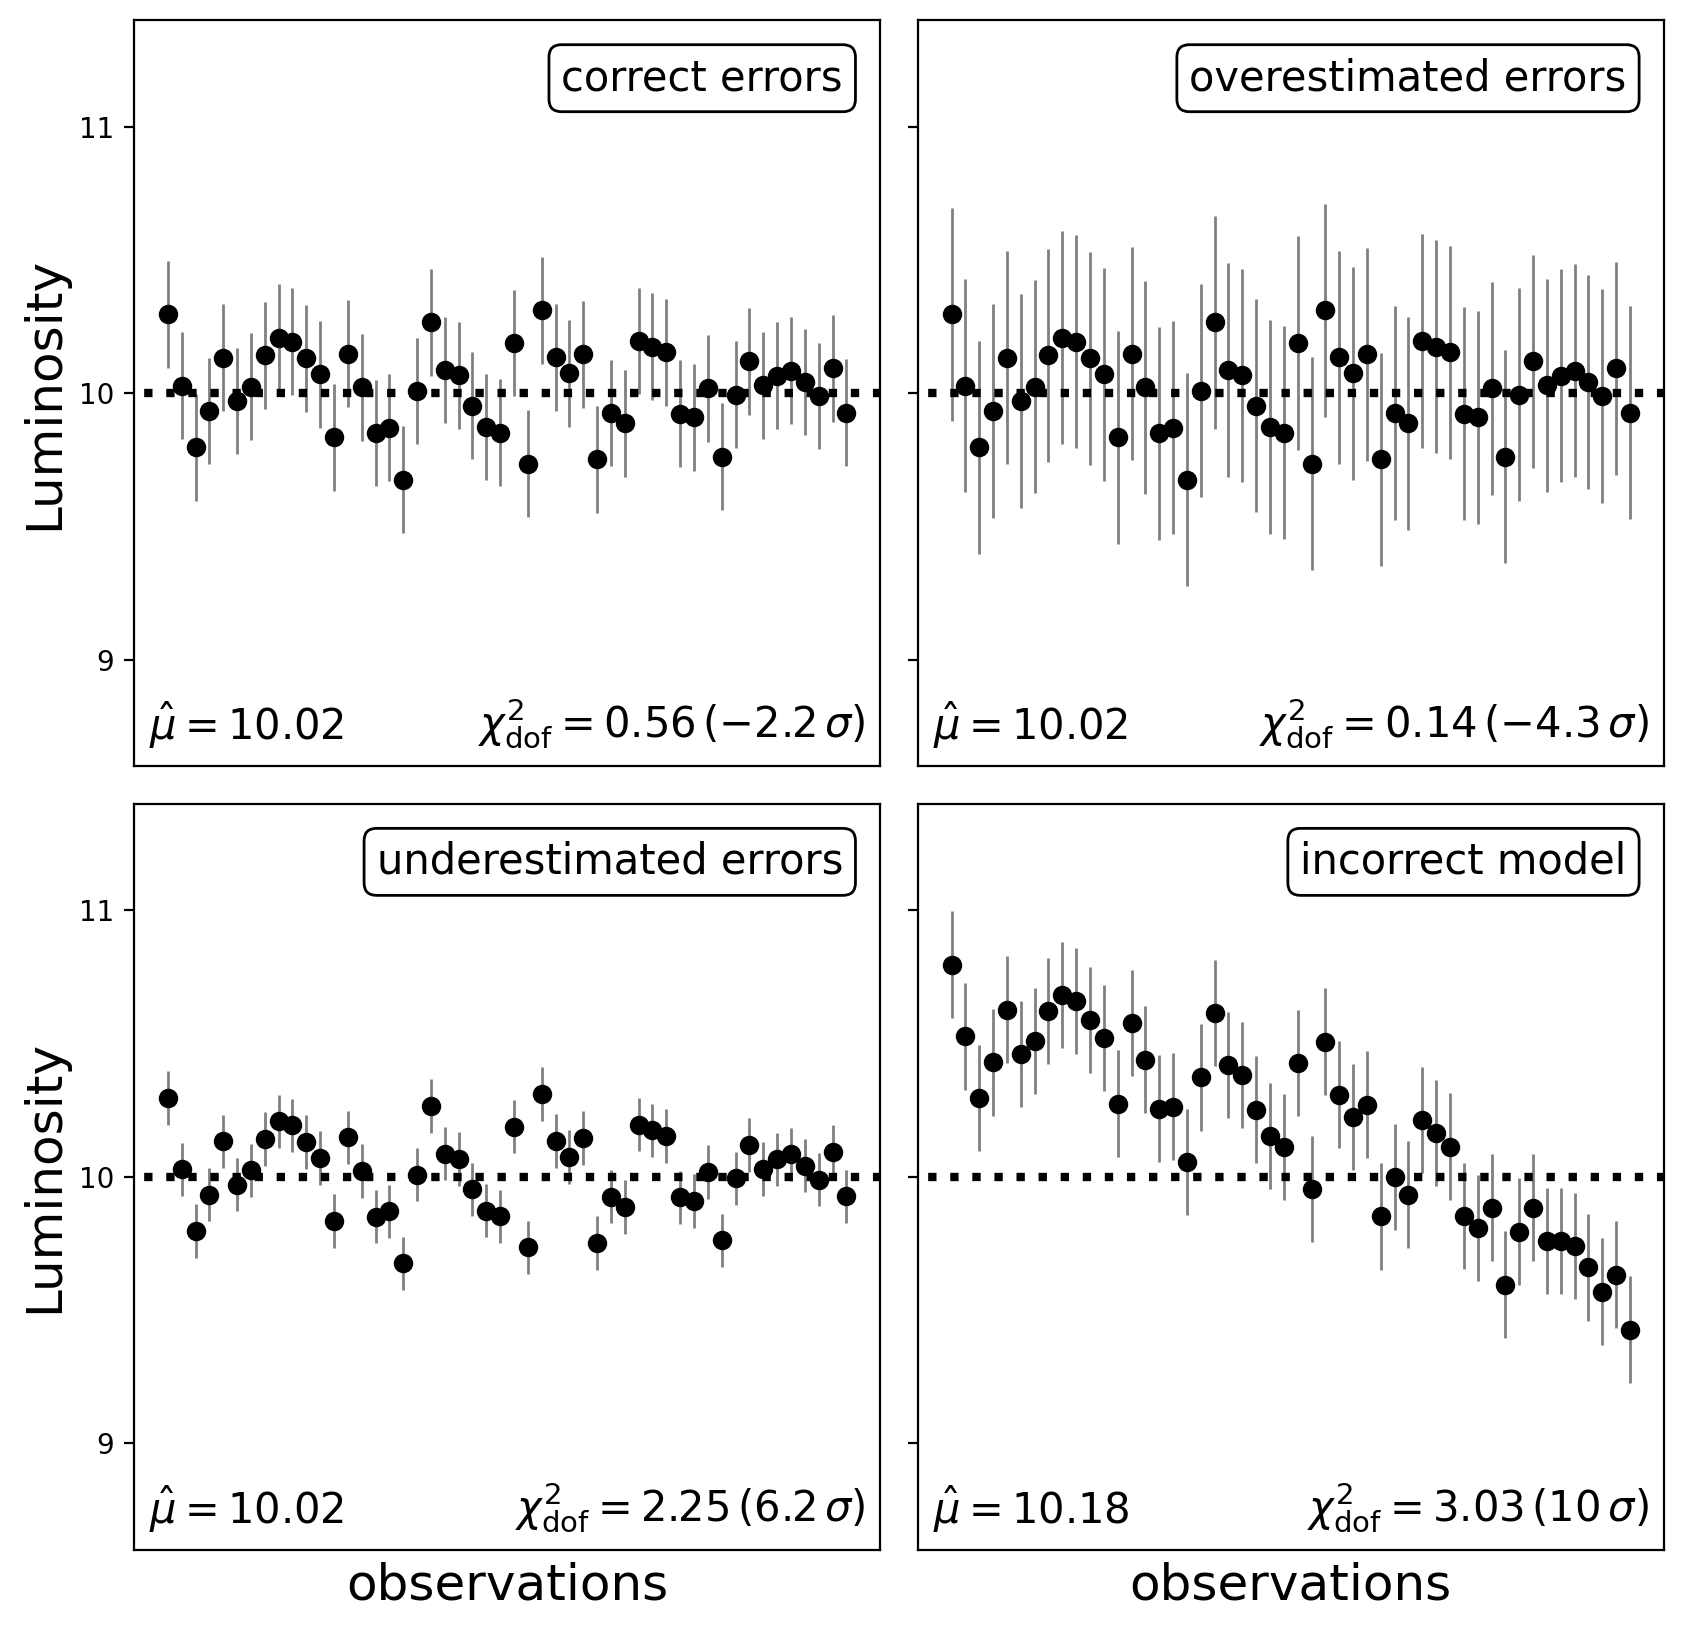

In [12]:
# Plot the results
fig = plt.figure(figsize=(9, 9))
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

for i in range(4):
    ax = fig.add_subplot(2, 2, 1 + i, xticks=[])

    # compute the mean and the chi^2/dof
    mu = np.mean(y_vals[i])
    z = (y_vals[i] - mu) / y_errs[i]
    chi2 = np.sum(z ** 2)
    chi2dof = chi2 / (N - 1)

    # compute the standard deviations of chi^2/dof
    sigma = np.sqrt(2. / (N - 1)) # Square root of 2/DOF
    nsig = (chi2dof - 1) / sigma

    # plot the points with errorbars
    ax.errorbar(t, y_vals[i], y_errs[i],fmt='.k', ecolor='gray', lw=1,ms = 12)
    ax.plot([-0.1, 1.3], [luminosity, luminosity], ':k', lw=3)

    # Add labels and text
    ax.text(0.95, 0.95, titles[i], ha='right', va='top',
            transform=ax.transAxes,fontsize = 15,
            bbox=dict(boxstyle='round', fc='w', ec='k'))
    ax.text(0.02, 0.02, r'$\hat{\mu} = %.2f$' % mu, ha='left', va='bottom',
            transform=ax.transAxes, fontsize = 15)
    ax.text(0.98, 0.02, r'$\chi^2_{\rm dof} = %.2f\, (%.2g\,\sigma)$'
            % (chi2dof, nsig), ha='right', va='bottom', 
            transform=ax.transAxes,fontsize = 15)

    # set axis limits
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(8.6, 11.4)

    # set ticks and labels
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))
    if i > 1: ax.set_xlabel('observations', fontsize = 18)
    if i % 2 == 0: ax.set_ylabel('Luminosity',fontsize = 18)
    else: ax.yaxis.set_major_formatter(plt.NullFormatter())


So here we can see that:

1. $\chi^2_{dof} \approx 1$ indicates that the model fits the data well
2. $\chi^2_{dof} << 1$ indicates that the errors are overestimated
3. $\chi^2_{dof} >> 1$ Indicates that the errors are underestimated or that the model is incorrect.

Lets now compute $\chi^2_{\text{dof}}$ for the line with outliers and without

In [13]:
# number of data points *without* outliers
N = x[4:].shape[0]
# number of data points *with* outliers
N_outlier = x.shape[0]
# number of model parameters (a,b)
k = 2 

print(x[4:].shape)

# chi2 per dof *without* outliers
chi2 = squared_loss(beta_mle[0], 
                    beta_mle[1], 
                    x=x[4:], y=y[4:], dy=dy[4:])
chi2dof = chi2 / (N-k)

# chi2 per dof *with* outliers
chi2_outlier = squared_loss(beta_mle1[0], 
                            beta_mle1[1], 
                            x=x, y=y, dy=dy)
chi2dof_outlier = chi2_outlier / (N_outlier - k)

# without outliers
found =  chi2dof-1
expected = np.sqrt(2/(N-k))

print("Without outlier. chi2dof-1:", found, "std:", expected, "Nsigma:", found/expected)

# with outliers
found =  chi2dof_outlier-1
expected = np.sqrt(2/(N_outlier-k))

print("With outlier. chi2dof-1:", found, "std:", expected, "Nsigma:", found/expected)


(16,)
Without outlier. chi2dof-1: 0.33434070794594706 std: 0.3779644730092272 Nsigma: 0.8845823663902529
With outlier. chi2dof-1: 15.109095710111468 std: 0.3333333333333333 Nsigma: 45.327287130334405


Based on these outliers we have a few possible causes:

1. The four objects belong to different populations
2. Their uncertainties are underestimated
3. There is additional intrinsic scatter

#### Occam's razor

We want a different approach when the models we are comparing have different number of parameters. This approach should penalize models with additional parameters that are not constrained by the data. This is called Occam penalty.

Here, simplicity should be preferred over complexity.

Here we can use AIC.

### Model comparison

Given the maximum likelihood for a set of models, the model with the largest value provides the best description of the data. However, we need to take into account model complexity and penalize models for additional parameters not supported by the data. Hence a scoring system can be adopted.

##### Corrected Akaike Information Criterion (AICc)

The AICc is a simple approach based on asymptotic approximation (the best one is cross validation but this is easy to use).

We can compute it as:

$$\text{AICc} \equiv -2\ln{L^0(M)} +2k + \frac{2k(k+1)}{N-k-1}$$
where $L_0(M)$ is the maximised likelihood for model M, k is the number of fitted parameters and N is the number of data points.

When comparing models, the one with the smallest AICc is the best model to select. If they are equally successful in describing the data, then the model with the fewer parameters wins.

###### Comparing likelihoods

We can also rank different models based on their computed maximum likelihood values. This is only fair when the models have the same number of parameters.

Doing that for the squared loss function and the Huber loss function:

In [14]:
# compute a quantity related to lnL0 for the 
# squared loss function
lnL_sq = - squared_loss(beta_mle1[0], 
                        beta_mle1[1], 
                        x=x, y=y, dy=dy)

# compute a quantity related to lnL0 for the 
# Huber loss function
lnL_huber = - huber_loss(beta_huber[0], 
                         beta_huber[1], 
                         x=x, y=y, dy=dy, c=c)

print("Maximum log likelihood for squared loss = %.1f" % lnL_sq)
print("Maximum log likelihood for Huber loss = %.1f" % lnL_huber)


Maximum log likelihood for squared loss = -290.0
Maximum log likelihood for Huber loss = -128.2


Here we can see that the Huber loss function follows the main population better and is less affected by the outliers.

However, these loss values are on different scales, so they should not be treated as a direct likelihood ratio.

### Confidence Estimating: Bootstrap and Jackknife

A lot of ways for computing confidence limits and uncertainties on measured model parameters assume the distribution is Gaussian and our samples are large.

From any sample, ${x}$ we can calculate an estimator: $\hat{\theta} = T(x_1,...,x_N)$.

If we only have one observed data set, we can only obtain one observed value, $\hat{\theta}$

We can repeatedly sample the distribution to find the sampling distribution of the estimator.

Bootstrap and Jackknife approximate it using only the observed data

##### Bootstrap

Here, we map the uncertainty of model parameters by resampling from our data, with replacement, B times.

We are seemingly creating information out of nothing. With B new bootstrap datasets, we compute our statistic on each to obtain B measures of our parameters.

A value may appear many times as it is with replacement, but this is fine as it replicates getting the same measurements in real data.

Example:

1. We have an original dataset of 1000 points drawn from a Gaussian distribution.
2. We can only measure the standard deviation of the distribution once with this dataset.
3. Our previous strategies showed that we can use a Fisher estimate or an analytic estimate of the sample standard deviation uncertainty.
4. Instead, we use the bootstrap method to resample the data 10,000 times, and compute the standard deviation and $\sigma_G$ on each new dataset.
5. This will map out the uncertainty distribution of those statistics, allowing us to quote confidence limits in our actual measured value

Example bootstrap:

In [15]:
data = np.array([2, 4, 5, 9, 10])
rng = np.random.default_rng(42)

print("Original data:", data)
print()

for i in range(4):
    sample = rng.choice(
        data,
        size=len(data),
        replace=True
    )
    print(f"Bootstrap sample {i + 1}: {sample}")


Original data: [ 2  4  5  9 10]

Bootstrap sample 1: [2 9 9 5 5]
Bootstrap sample 2: [10  2  9  4  2]
Bootstrap sample 3: [ 5 10  9  9  9]
Bootstrap sample 4: [ 9  5  2 10  5]


Mathematically, the bootstrap treats the empirical distribution:

$$f(x)=\frac{1}{N}\sum_{i=1}^{N}\delta(x-x_i)$$

as an approximation to the unknown true population distribution

### Uncertainty in Gaussian Width

We generate $N=1000$ measurements from a standard Gaussian and estimate its width in two ways.

The ordinary sample standard deviation is sensitive to every value.

The robust width

$$
\sigma_G=0.7413\left(q_{0.75}-q_{0.25}\right)
$$

uses the interquartile range. Because it focuses on the middle $50\%$ of the data, a few extreme outliers have much less influence.

We only have one dataset, so each statistic gives one measured width. Bootstrap will show how those measured widths vary across resampled datasets.

In [16]:
def sigma_G(values, axis=None):
    q25, q75 = np.percentile(values,[25, 75],axis=axis)
    return 0.7413 * (q75 - q25)


N = 1000
B = 10000

np.random.seed(11)
data = norm(0, 1).rvs(N)

rng = np.random.default_rng(11)

# Each row is one new bootstrap dataset.
indices = rng.integers(0,N,size=(B, N))
bootstrap_samples = data[indices]

# One statistic is calculated for every row.
std_bootstrap = np.std(bootstrap_samples,axis=1,ddof=1)
sigmaG_bootstrap = sigma_G(bootstrap_samples,axis=1)

print("One observed dataset gives:")
print(f"sample standard deviation = {np.std(data, ddof=1):.4f}")
print(f"sigma_G                   = {sigma_G(data):.4f}")
print()
print("The bootstrap distributions have widths:")
print(f"SE of standard deviation  = {std_bootstrap.std(ddof=1):.4f}")
print(f"SE of sigma_G             = {sigmaG_bootstrap.std(ddof=1):.4f}")


One observed dataset gives:
sample standard deviation = 1.0085
sigma_G                   = 0.9948

The bootstrap distributions have widths:
SE of standard deviation  = 0.0221
SE of sigma_G             = 0.0364


The code creates an array with shape $(B,N)$:

1. each row is one bootstrap dataset
2. each row contains $N$ draws
3. the statistic is calculated along axis=1
4. the result is $B$ different estimates

The standard deviation of those $B$ estimates is the bootstrap standard error.

For Gaussian data, the expected standard errors are approximately

$$
\mathrm{SE}(s)\approx\frac{1}{\sqrt{2(N-1)}}
$$

and

$$
\mathrm{SE}(\sigma_G)\approx\frac{1.06}{\sqrt{N}}.
$$

We now compare the bootstrap result with those analytic expectations.

Standard deviation:
bootstrap SE = 0.02207
theory SE    = 0.02237

sigma_G:
bootstrap SE = 0.03638
theory SE    = 0.03352


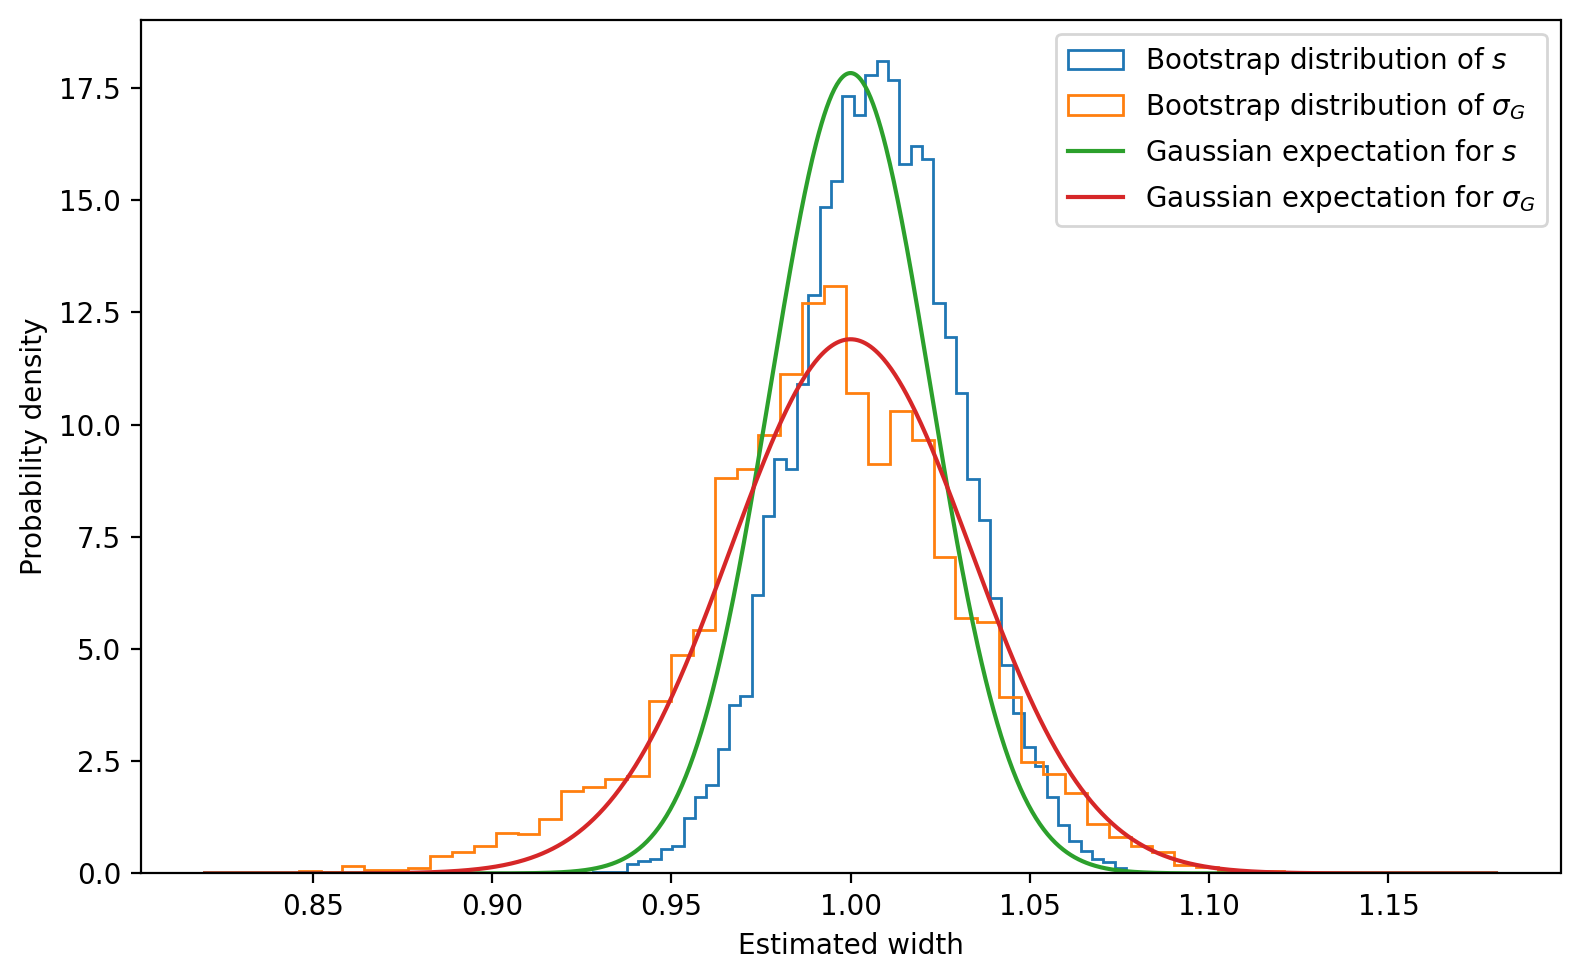

In [17]:
theory_std_error = 1 / np.sqrt(2 * (N - 1))
theory_sigmaG_error = 1.06 / np.sqrt(N)

print("Standard deviation:")
print(f"bootstrap SE = {std_bootstrap.std(ddof=1):.5f}")
print(f"theory SE    = {theory_std_error:.5f}")
print()
print("sigma_G:")
print(f"bootstrap SE = {sigmaG_bootstrap.std(ddof=1):.5f}")
print(f"theory SE    = {theory_sigmaG_error:.5f}")


xgrid = np.linspace(0.82, 1.18, 1000)

plt.figure(figsize=(8, 5))

plt.hist(
    std_bootstrap,
    bins=50,
    density=True,
    histtype="step",
    label=r"Bootstrap distribution of $s$"
)

plt.hist(
    sigmaG_bootstrap,
    bins=50,
    density=True,
    histtype="step",
    label=r"Bootstrap distribution of $\sigma_G$"
)

plt.plot(
    xgrid,
    norm(1, theory_std_error).pdf(xgrid),
    label=r"Gaussian expectation for $s$"
)

plt.plot(
    xgrid,
    norm(1, theory_sigmaG_error).pdf(xgrid),
    label=r"Gaussian expectation for $\sigma_G$"
)

plt.xlabel("Estimated width")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()


## Bootstrap Confidence Intervals

Because bootstrap produces the full distribution of the estimator, we can use its percentiles as confidence limits.

A simple $95\%$ percentile interval is:

$$
\left[q_{0.025},q_{0.975}\right]
$$

This does not mean there is a $95\%$ probability that a fixed true parameter lies inside this particular interval. The frequentist interpretation is that the procedure would cover the true value in about $95\%$ of repeated experiments under suitable conditions.

In [18]:
std_interval = np.percentile(std_bootstrap,[2.5, 97.5])

sigmaG_interval = np.percentile(sigmaG_bootstrap,[2.5, 97.5])

print("95% bootstrap interval for s:")
print(std_interval)
print()
print("95% bootstrap interval for sigma_G:")
print(sigmaG_interval)


95% bootstrap interval for s:
[0.9638745  1.05068869]

95% bootstrap interval for sigma_G:
[0.91490214 1.06312519]


##### Jackknife

The Jackknife method removes one point at a time from our original dataset and calculates the statistic again.

For a dataset of $N$ points, this gives $N$ new datasets, each with $N-1$ points.

If $\alpha_N$ is the statistic from the full dataset and $\alpha_i^*$ is the statistic when point $i$ is removed, the bias corrected estimate is:

$$
\alpha^J = N\alpha_N - (N-1)\bar{\alpha}^*
$$

The Jackknife standard error is:

$$
\sigma_\alpha =
\sqrt{
\frac{N-1}{N}
\sum_{i=1}^{N}
\left(
\alpha_i^*-\bar{\alpha}^*
\right)^2
}
$$

In [19]:
def jackknife(data, statistic):
    N = len(data)
    full_estimate = statistic(data)

    jackknife_estimates = np.array([
        statistic(np.delete(data, i))
        for i in range(N)
    ])

    mean_jackknife = np.mean(jackknife_estimates)

    corrected_estimate = (
        N * full_estimate
        - (N - 1) * mean_jackknife
    )

    standard_error = np.sqrt(
        (N - 1) / N
        * np.sum(
            (jackknife_estimates - mean_jackknife) ** 2
        )
    )

    return corrected_estimate, standard_error, jackknife_estimates


std_jackknife, std_jackknife_error, std_jackknife_values = jackknife(
    data,
    lambda values: np.std(values, ddof=1)
)

sigmaG_jackknife, sigmaG_jackknife_error, sigmaG_jackknife_values = jackknife(
    data,
    sigma_G
)

print("Standard deviation:")
print(f"Jackknife estimate = {std_jackknife:.5f}")
print(f"Jackknife SE       = {std_jackknife_error:.5f}")
print()
print("sigma_G:")
print(f"Jackknife estimate = {sigmaG_jackknife:.5f}")
print(f"Jackknife SE       = {sigmaG_jackknife_error:.5f}")

Standard deviation:
Jackknife estimate = 1.00876
Jackknife SE       = 0.02194

sigma_G:
Jackknife estimate = 0.92138
Jackknife SE       = 0.04808


The Jackknife works well for the standard deviation because removing one point usually changes the value slightly.

However, $\sigma_G$ depends on the quartiles. Removing one point often does not change either quartile, so many Jackknife datasets give the same value.

This means the standard leave-one-out Jackknife can fail for rank based statistics such as medians, quartiles and $\sigma_G$.

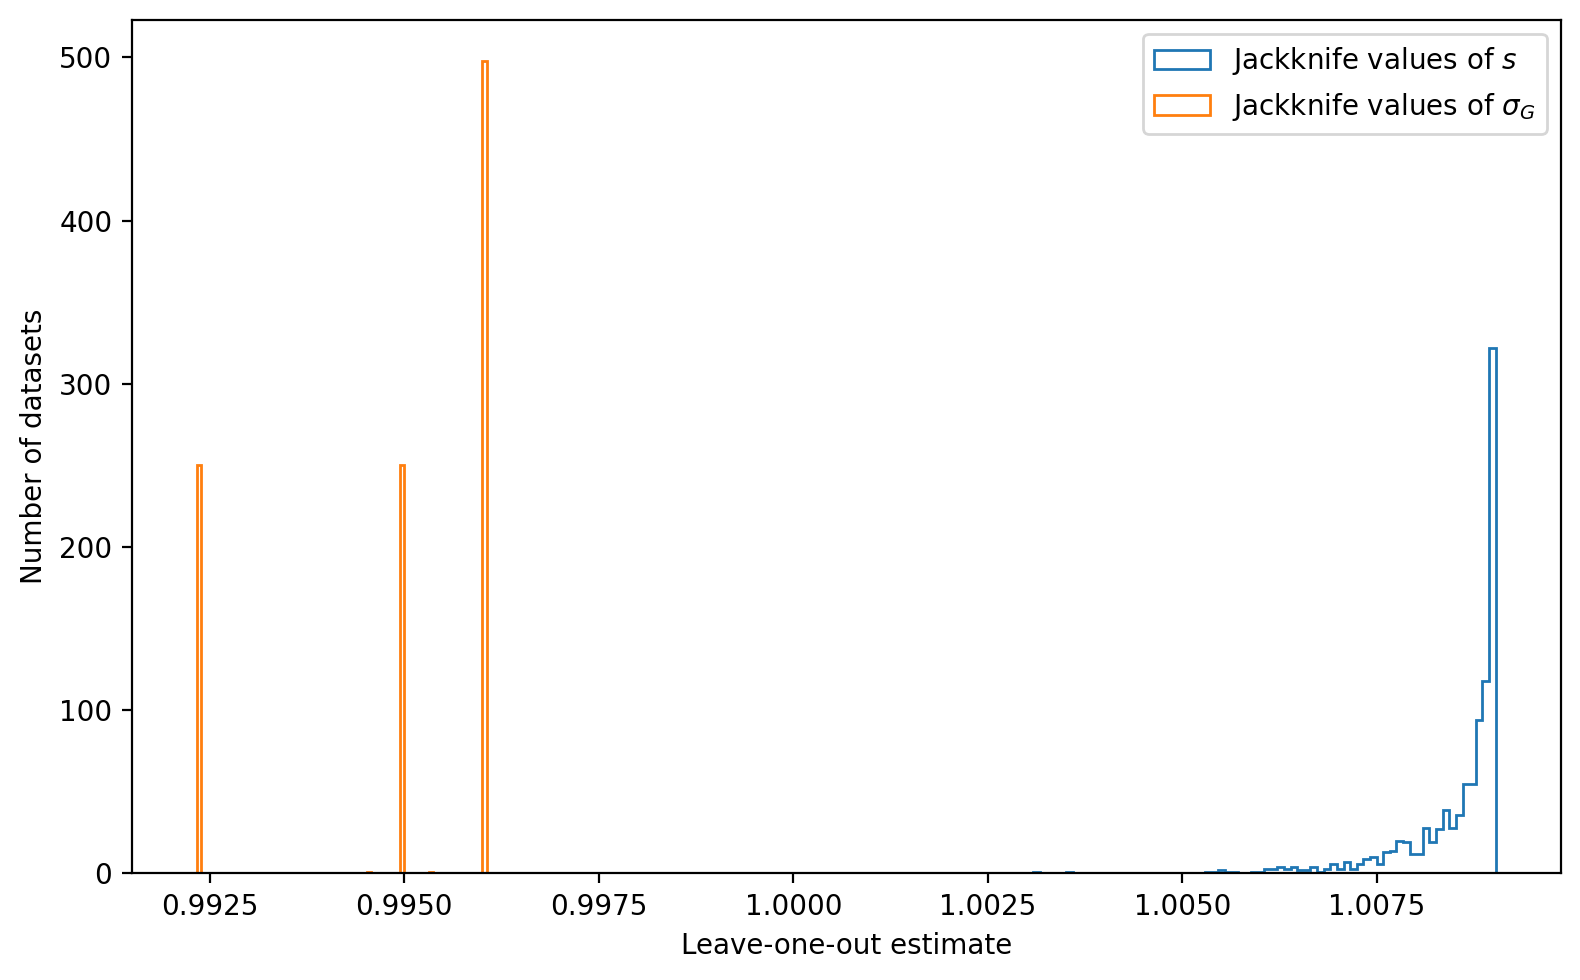

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    std_jackknife_values,
    bins=70,
    histtype="step",
    label=r"Jackknife values of $s$"
)

plt.hist(
    sigmaG_jackknife_values,
    bins=70,
    histtype="step",
    label=r"Jackknife values of $\sigma_G$"
)

plt.xlabel("Leave-one-out estimate")
plt.ylabel("Number of datasets")
plt.legend()
plt.tight_layout()
plt.show()